# Exploração das camadas Bronze, Silver e Gold

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import pyarrow.parquet as pq

## Localização das camadas

In [2]:
pasta_atual = Path.cwd()

if pasta_atual.name == 'notebooks':
    raiz_projeto = pasta_atual.parent
else:
    raiz_projeto = pasta_atual

pastas_camadas = {
    'bronze': raiz_projeto / 'data' / 'bronze',
    'silver': raiz_projeto / 'data' / 'silver',
    'gold': raiz_projeto / 'data' / 'gold',
}

for camada, caminho in pastas_camadas.items():
    print(camada, '->', caminho)

bronze -> C:\Users\claud\Documents\Py\tech_challenge_02\data\bronze
silver -> C:\Users\claud\Documents\Py\tech_challenge_02\data\silver
gold -> C:\Users\claud\Documents\Py\tech_challenge_02\data\gold


## Funções de apoio

In [3]:
def arquivos_parquet(caminho_tabela):
    return sorted(caminho_tabela.rglob('*.parquet'))


def resumir_tabela(camada, caminho_tabela):
    arquivos = arquivos_parquet(caminho_tabela)

    if not arquivos:
        return None

    quantidade_registros = 0
    tamanho_bytes = 0

    for arquivo in arquivos:
        parquet = pq.ParquetFile(arquivo)
        quantidade_registros += parquet.metadata.num_rows
        tamanho_bytes += arquivo.stat().st_size

    primeira_tabela = pq.ParquetFile(arquivos[0])

    return {
        'camada': camada,
        'tabela': caminho_tabela.name,
        'arquivos': len(arquivos),
        'registros': quantidade_registros,
        'colunas': len(primeira_tabela.schema_arrow.names),
        'tamanho_mb': round(tamanho_bytes / 1024 / 1024, 2),
    }


def ler_amostra(caminho_tabela, quantidade=5):
    arquivos = arquivos_parquet(caminho_tabela)

    if not arquivos:
        raise FileNotFoundError(f'Nenhum Parquet encontrado em {caminho_tabela}')

    parquet = pq.ParquetFile(arquivos[0])
    amostra = parquet.read_row_group(0).slice(0, quantidade)
    return amostra.to_pandas()

## Inventário das três camadas

In [4]:
resumo_camadas = []

for camada, pasta_camada in pastas_camadas.items():
    for caminho_tabela in sorted(pasta_camada.iterdir()):
        if caminho_tabela.is_dir():
            resumo = resumir_tabela(camada, caminho_tabela)
            if resumo is not None:
                resumo_camadas.append(resumo)

df_resumo_camadas = pd.DataFrame(resumo_camadas)
display(df_resumo_camadas)

,camada,tabela,arquivos,registros,colunas,tamanho_mb
0,bronze,alunos,1,3867999,16,81.89
1,bronze,meta_alfabetizacao_brasil,1,3,15,0.01
2,bronze,meta_alfabetizacao_municipio,1,10704,17,0.21
3,bronze,meta_alfabetizacao_uf,1,54,16,0.01
4,bronze,municipio,1,23995,19,0.48
5,bronze,uf,1,145,19,0.02
6,silver,alunos,1,3867999,17,68.20
7,silver,meta_alfabetizacao_brasil,1,3,16,0.01
8,silver,meta_alfabetizacao_municipio,1,10704,18,0.22
9,silver,meta_alfabetizacao_uf,1,54,17,0.01


In [5]:
tabelas_por_camada = (
    df_resumo_camadas
    .groupby('camada', as_index=False)
    .agg(tabelas=('tabela', 'count'), registros=('registros', 'sum'))
)

display(tabelas_por_camada)


,camada,tabelas,registros
0,bronze,6,3902900
1,gold,3,10324
2,silver,6,3902900


## Comparação entre Bronze e Silver

In [6]:
comparacao = (
    df_resumo_camadas[df_resumo_camadas['camada'].isin(['bronze', 'silver'])]
    .pivot(index='tabela', columns='camada', values='registros')
    .reset_index()
)
comparacao['diferenca'] = comparacao['silver'] - comparacao['bronze']
comparacao['quantidades_iguais'] = comparacao['diferenca'] == 0
display(comparacao)

camada,tabela,bronze,silver,diferenca,quantidades_iguais
0,alunos,3867999,3867999,0,True
1,meta_alfabetizacao_brasil,3,3,0,True
2,meta_alfabetizacao_municipio,10704,10704,0,True
3,meta_alfabetizacao_uf,54,54,0,True
4,municipio,23995,23995,0,True
5,uf,145,145,0,True


Evolução da tabela de alunos

In [7]:
amostra_alunos_bronze = ler_amostra(pastas_camadas['bronze'] / 'alunos')
amostra_alunos_silver = ler_amostra(pastas_camadas['silver'] / 'alunos')

print('Amostra Bronze')
display(amostra_alunos_bronze)
print(amostra_alunos_bronze.dtypes)

print('Amostra Silver')
display(amostra_alunos_silver)
print(amostra_alunos_silver.dtypes)

Amostra Bronze


,ano,id_municipio,id_escola,id_aluno,caderno,serie,rede,presenca,preenchimento_caderno,alfabetizado,proficiencia,peso_aluno,_id_ingestao,_data_ingestao,_arquivo_origem,_tabela_origem
0,2023,2211001,60006464,22034323,1,2,3,0,0,0,<NA>,<NA>,a28512e0-d34b-42cc-83b7-5257432c1977,2026-08-30T18:59:27,C:\Users\claud\Documents\Py\tech_challenge_02\...,alunos
1,2023,2607901,60012705,26043437,1,2,3,0,0,0,<NA>,<NA>,a28512e0-d34b-42cc-83b7-5257432c1977,2026-08-30T18:59:27,C:\Users\claud\Documents\Py\tech_challenge_02\...,alunos
2,2023,5107602,60041216,51032559,1,2,3,0,0,0,<NA>,<NA>,a28512e0-d34b-42cc-83b7-5257432c1977,2026-08-30T18:59:27,C:\Users\claud\Documents\Py\tech_challenge_02\...,alunos
3,2024,1503705,60003040,15037742,1,2,3,0,0,0,<NA>,<NA>,a28512e0-d34b-42cc-83b7-5257432c1977,2026-08-30T18:59:27,C:\Users\claud\Documents\Py\tech_challenge_02\...,alunos
4,2024,4128203,60033267,41138160,1,2,3,0,0,0,<NA>,<NA>,a28512e0-d34b-42cc-83b7-5257432c1977,2026-08-30T18:59:27,C:\Users\claud\Documents\Py\tech_challenge_02\...,alunos


ano                      string[python]
id_municipio             string[python]
id_escola                string[python]
id_aluno                 string[python]
caderno                  string[python]
serie                    string[python]
rede                     string[python]
presenca                 string[python]
preenchimento_caderno    string[python]
alfabetizado             string[python]
proficiencia             string[python]
peso_aluno               string[python]
_id_ingestao                     object
_data_ingestao                   object
_arquivo_origem                  object
_tabela_origem                   object
dtype: object
Amostra Silver


,ano,id_municipio,id_escola,id_aluno,caderno,serie,rede,presenca,preenchimento_caderno,alfabetizado,proficiencia,peso_aluno,_id_ingestao,_data_ingestao,_arquivo_origem,_tabela_origem,_data_tratamento
0,2023,2211001,60006464,22034323,1,2,3,0,0,0,<NA>,<NA>,a28512e0-d34b-42cc-83b7-5257432c1977,2026-08-30 18:59:27,C:\Users\claud\Documents\Py\tech_challenge_02\...,alunos,2026-08-30 20:09:48.850243
1,2023,2607901,60012705,26043437,1,2,3,0,0,0,<NA>,<NA>,a28512e0-d34b-42cc-83b7-5257432c1977,2026-08-30 18:59:27,C:\Users\claud\Documents\Py\tech_challenge_02\...,alunos,2026-08-30 20:09:48.850243
2,2023,5107602,60041216,51032559,1,2,3,0,0,0,<NA>,<NA>,a28512e0-d34b-42cc-83b7-5257432c1977,2026-08-30 18:59:27,C:\Users\claud\Documents\Py\tech_challenge_02\...,alunos,2026-08-30 20:09:48.850243
3,2024,1503705,60003040,15037742,1,2,3,0,0,0,<NA>,<NA>,a28512e0-d34b-42cc-83b7-5257432c1977,2026-08-30 18:59:27,C:\Users\claud\Documents\Py\tech_challenge_02\...,alunos,2026-08-30 20:09:48.850243
4,2024,4128203,60033267,41138160,1,2,3,0,0,0,<NA>,<NA>,a28512e0-d34b-42cc-83b7-5257432c1977,2026-08-30 18:59:27,C:\Users\claud\Documents\Py\tech_challenge_02\...,alunos,2026-08-30 20:09:48.850243


ano                               Int64
id_municipio             string[python]
id_escola                string[python]
id_aluno                 string[python]
caderno                           Int64
serie                             Int64
rede                     string[python]
presenca                          Int64
preenchimento_caderno             Int64
alfabetizado                      Int64
proficiencia                    Float64
peso_aluno                      Float64
_id_ingestao             string[python]
_data_ingestao           datetime64[ns]
_arquivo_origem          string[python]
_tabela_origem           string[python]
_data_tratamento         datetime64[us]
dtype: object


Exploração da camada Gold

In [8]:
gold_municipio = pd.read_parquet(
    pastas_camadas['gold'] / 'indicadores_municipio' / 'data.parquet'
)
gold_uf = pd.read_parquet(
    pastas_camadas['gold'] / 'indicadores_uf' / 'data.parquet'
)
gold_brasil = pd.read_parquet(
    pastas_camadas['gold'] / 'indicadores_brasil' / 'data.parquet'
)

print('Municípios:', len(gold_municipio))
print('UFs:', len(gold_uf))
print('Brasil:', len(gold_brasil))

Municípios: 10272
UFs: 49
Brasil: 3


Situação das metas estaduais em 2024

,quantidade_ufs
situacao_meta,
Não atingida,13
Atingida,11
Sem meta,1


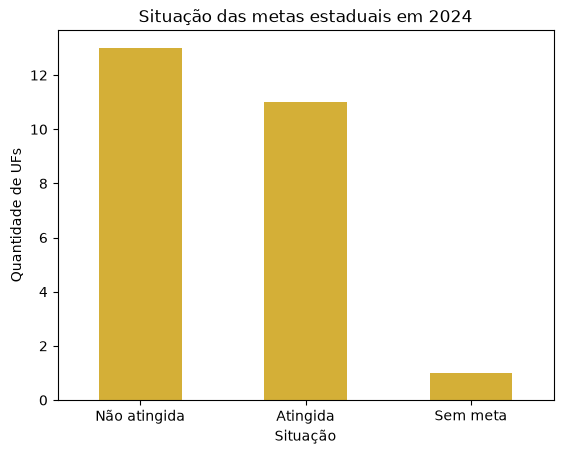

In [9]:
situacao_uf_2024 = (
    gold_uf[gold_uf['ano'] == 2024]
    .groupby('situacao_meta')
    .size()
    .sort_values(ascending=False)
)

display(situacao_uf_2024.rename('quantidade_ufs').to_frame())

situacao_uf_2024.plot(
    kind='bar',
    color='#d4af37',
    title='Situação das metas estaduais em 2024',
)
plt.xlabel('Situação')
plt.ylabel('Quantidade de UFs')
plt.xticks(rotation=0)
plt.show()

UFs com maiores e menores diferenças para a meta

In [10]:
ranking_uf = (
    gold_uf[(gold_uf['ano'] == 2024) & gold_uf['diferenca_para_meta'].notna()]
    [['sigla_uf', 'taxa_oficial', 'meta_do_ano', 'diferenca_para_meta', 'situacao_meta']]
    .sort_values('diferenca_para_meta', ascending=False)
)

print('Maiores diferenças positivas')
display(ranking_uf.head(5))

print('Maiores diferenças negativas')
display(ranking_uf.tail(5).sort_values('diferenca_para_meta'))

Maiores diferenças positivas


,sigla_uf,taxa_oficial,meta_do_ano,diferenca_para_meta,situacao_meta
26,MG,72.07,63.2,8.87,Atingida
24,CE,85.31,80.0,5.31,Atingida
27,GO,72.74,68.9,3.84,Atingida
42,MS,55.87,52.8,3.07,Atingida
29,PI,59.82,57.0,2.82,Atingida


Maiores diferenças negativas


,sigla_uf,taxa_oficial,meta_do_ano,diferenca_para_meta,situacao_meta
44,RS,44.67,66.2,-21.53,Não atingida
38,AM,49.17,56.8,-7.63,Não atingida
36,BA,35.96,43.4,-7.44,Não atingida
43,PA,48.2,53.6,-5.4,Não atingida
46,RN,39.29,43.8,-4.51,Não atingida


Evolução do indicador nacional

,ano,taxa_oficial,percentual_participacao,meta_alfabetizacao_2024,meta_do_ano,diferenca_para_meta,situacao_meta,_data_criacao_gold
2,2023,55.9,86.0,59.9,<NA>,<NA>,Sem meta,2026-08-30 20:30:48.983169
1,2024,59.2,87.37,59.9,59.9,-0.7,Não atingida,2026-08-30 20:30:48.983169
0,2025,66.0,88.0,60.0,<NA>,<NA>,Sem meta,2026-08-30 20:30:48.983169


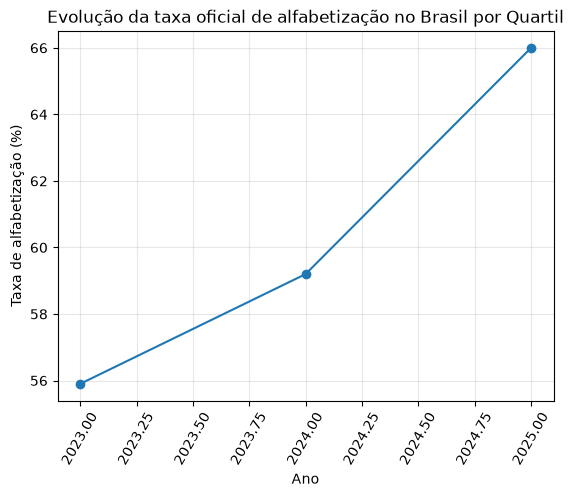

In [16]:
evolucao_brasil = gold_brasil.sort_values('ano')
display(evolucao_brasil)

evolucao_brasil.plot(
    x='ano',
    y='taxa_oficial',
    marker='o',
    legend=False,
    color='#1f77b4',
    title='Evolução da taxa oficial de alfabetização no Brasil por Quartil',
)
plt.xticks(rotation=60)
plt.xlabel('Ano')
plt.ylabel('Taxa de alfabetização (%)')
plt.grid(alpha=0.3)
plt.show()